In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv('C:\\Users\\ABC\\AppData\\Local\\Temp\\Rar$DIa23148.15608\\train.csv', usecols=['Age','Fare','Survived'])
df.head()


,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [3]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [4]:
df['Age'].fillna(df['Age'].mean(), inplace=True)
df.head()

C:\Users\ABC\AppData\Local\Temp\ipykernel_15272\2675817237.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
x = df.iloc[:, 1:3]
y = df.iloc[:, 0]

In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

C:\Users\ABC\AppData\Local\Temp\ipykernel_15272\551715513.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'])


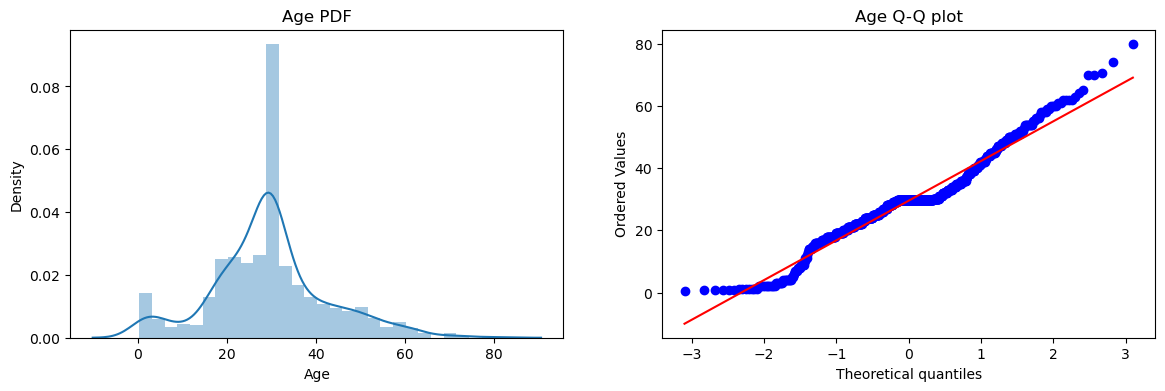

In [7]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train['Age'])
plt.title('Age PDF')
plt.subplot(122)
stats.probplot(x_train['Age'],dist='norm',plot=plt)
plt.title('Age Q-Q plot')
plt.show()


C:\Users\ABC\AppData\Local\Temp\ipykernel_15272\2667479955.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Fare'])


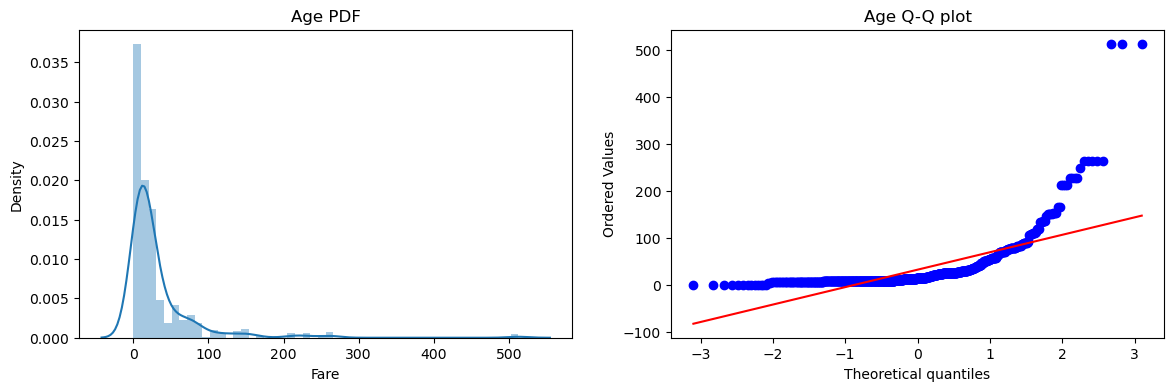

In [8]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train['Fare'])
plt.title('Age PDF')
plt.subplot(122)
stats.probplot(x_train['Fare'],dist='norm',plot=plt)
plt.title('Age Q-Q plot')
plt.show()


In [9]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [19]:
clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)
y_pred = clf.predict(x_test)
y_pred1 = clf2.predict(x_test)
print('Accuracy of Logistic Regression:', accuracy_score(y_test, y_pred))
print('Accuracy of Decision Tree:', accuracy_score(y_test, y_pred1))


Accuracy of Logistic Regression: 0.6480446927374302
Accuracy of Decision Tree: 0.6536312849162011


In [20]:
trf = FunctionTransformer(func=np.log1p)

In [21]:
x_train_trnsformed = trf.fit_transform(x_train)
x_test_trnsformed = trf.transform(x_test)

In [23]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()
clf.fit(x_train_trnsformed,y_train)
clf2.fit(x_train_trnsformed,y_train)
y_pred = clf.predict(x_test)
y_pred1 = clf2.predict(x_train)
print('Accuracy Logistic transformation:', accuracy_score(y_test, y_pred))
print('Accuracy of Decision Tree:', accuracy_score(y_test, y_pred1))


Accuracy Logistic transformation: 0.7374301675977654


ValueError: Found input variables with inconsistent numbers of samples: [179, 712]

In [28]:
x_trnsformed = trf.fit_transform(x)
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()
print("LR", np.mean(cross_val_score(clf, x_trnsformed, y,scoring='accuracy' ,cv=10)))
print("DT", np.mean(cross_val_score(clf2, x_trnsformed, y,scoring='accuracy', cv=10)))

LR 0.678027465667915
DT 0.6588389513108615


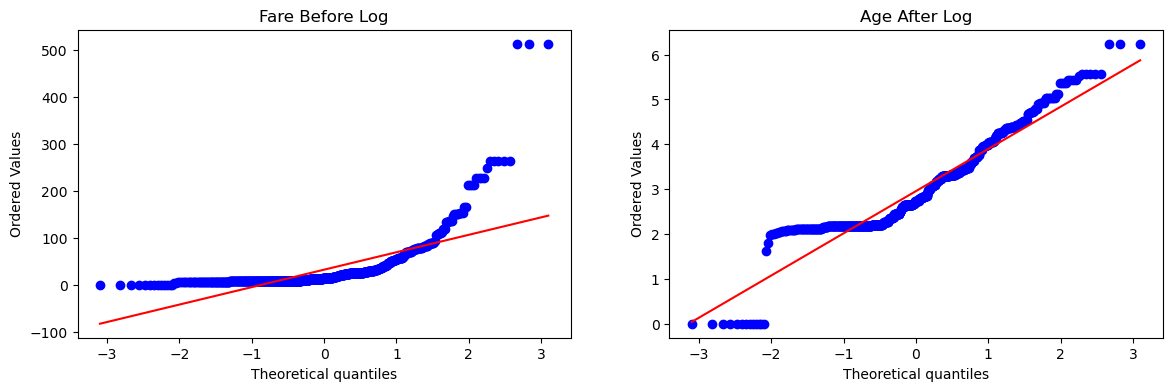

In [30]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(x_train['Fare'], dist='norm', plot=plt)
plt.title('Fare Before Log')
plt.subplot(122)
stats.probplot(x_train_trnsformed['Fare'],dist='norm',plot=plt)
plt.title('Age After Log')
plt.show()

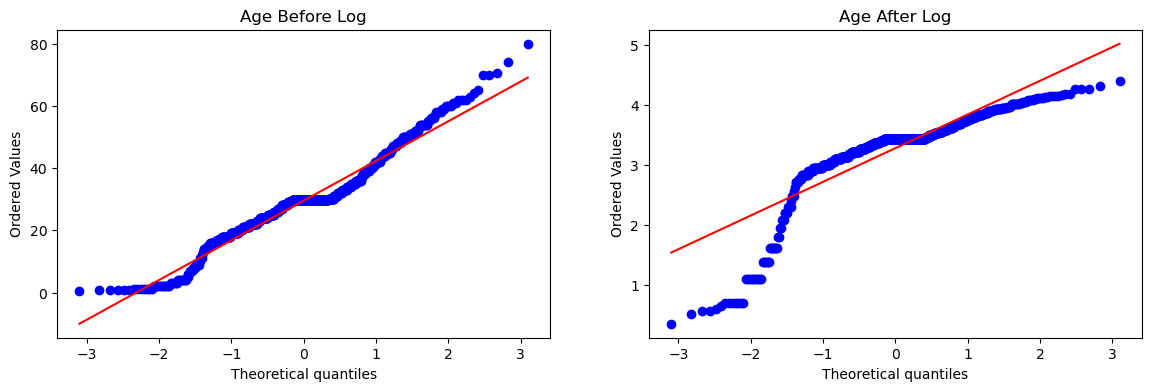

In [32]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(x_train['Age'], dist='norm', plot=plt)
plt.title('Age Before Log')
plt.subplot(122)
stats.probplot(x_train_trnsformed['Age'],dist='norm',plot=plt)
plt.title('Age After Log')
plt.show()

In [ ]:
trf = FunctionTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder= 'passthrough')
x_train_trnsformed = trf.transform(x_train)
x_test_trnsformed = trf.transform(x_test)

TypeError: FunctionTransformer.__init__() got an unexpected keyword argument 'remainder'